# ARIMAX Grid-Search Measles Forecast

This notebook reports the revised ARIMAX analysis. It no longer presents the model as AutoARIMA, because the order is chosen by an explicit grid search over ARIMAX(k,0,0) and ARIMAX(n,0,m) candidates.

The retained specification keeps `d=0`, a linear time term, and a one-year major-outbreak pulse. The notebook keeps the main outputs needed for reporting: model summary, grid-search results, parameter estimates with standard errors and 95% CIs, validation checks, Ljung-Box test, residual ACF/PACF plots, and the forecast figure.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 100)

## Run Analysis

The script below performs the AR and ARMA grid searches, fits the selected ARIMAX model, writes all CSV outputs, and saves the diagnostic plots.

In [2]:
%run revised_autoarimax_validation.py

                                                     model       exogenous_variables  forecast_count_year partial_2026_observed_date  partial_2026_observed_cumulative_cases full_year_2026_forecast_date  raw_forecast_cumulative_cases  forecast_cumulative_cases  raw_forecast_2026_cases_implied  forecast_2026_cases_implied                         historical_interval_method                      forecast_interval_method  calibration_error_95_cases  parametric_ci_lower_95_cases  parametric_ci_upper_95_cases  ci_lower_95  ci_upper_95       aic     order best_ar_order best_arma_order  conditional_burn_in_years                                                                      ar_order_selection_rule                                                                                        arma_order_selection_rule                                                                                                                                                                                         

## Main Model Summary

In [3]:
model_summary = pd.read_csv(ROOT / "revised_autoarimax_model_summary.csv")
model_summary[
    [
        "model",
        "order",
        "best_ar_order",
        "best_arma_order",
        "aic",
        "raw_forecast_2026_cases_implied",
        "forecast_2026_cases_implied",
        "ci_lower_95",
        "ci_upper_95",
        "ljung_box_min_p_value",
        "ljung_box_result",
    ]
]

,model,order,best_ar_order,best_arma_order,aic,raw_forecast_2026_cases_implied,forecast_2026_cases_implied,ci_lower_95,ci_upper_95,ljung_box_min_p_value,ljung_box_result
0,Revised ARIMAX grid-search annual increments to cumulative,"(2, 0, 0)","(2, 0, 0)","(2, 0, 0)",88.800728,397.712396,1814.0,84565.0,85908.779968,0.508823,no residual autocorrelation detected at alpha=0.05


## Grid-Search Report

The first table summarizes the selected AR-only and broader ARMA models. The next two tables provide the full AR(k) and ARMA(n,m) candidate grids used for model selection.

In [4]:
selected_order_summary = pd.read_csv(ROOT / "revised_autoarimax_selected_order_summary.csv")
selected_order_summary[
    [
        "model_family",
        "order",
        "aic",
        "ljung_box_min_p_value",
        "ljung_box_result",
        "ar_p_values",
        "arma_p_values",
        "order_selection_rule",
    ]
]

,model_family,order,aic,ljung_box_min_p_value,ljung_box_result,ar_p_values,arma_p_values,order_selection_rule
0,best_ar_k,"(2, 0, 0)",88.800728,0.508823,no residual autocorrelation detected at alpha=0.05,ar.L1=0.01167; ar.L2=0.03599,NaN,lowest AIC among k>0 candidates with all AR p-values < 0.05 and Ljung-Box min p-value > 0.05
1,best_arma_n_m,"(2, 0, 0)",88.800728,0.508823,no residual autocorrelation detected at alpha=0.05,NaN,ar.L1=0.01167; ar.L2=0.03599,lowest AIC among non-white-noise ARMA candidates with all AR/MA p-values < 0.05 and Ljung-Box mi...


In [5]:
ar_grid = pd.read_csv(ROOT / "revised_autoarimax_ar_order_selection.csv")
ar_grid[
    [
        "order",
        "aic",
        "ar_p_values",
        "all_ar_p_values_below_0_05",
        "ljung_box_min_p_value",
        "ljung_box_result",
        "selected",
    ]
]

,order,aic,ar_p_values,all_ar_p_values_below_0_05,ljung_box_min_p_value,ljung_box_result,selected
0,"(0, 0, 0)",133.965993,NaN,False,1.572406e-10,residual autocorrelation detected at alpha=0.05,False
1,"(1, 0, 0)",93.544834,ar.L1=9.666e-07,True,3.287383e-01,no residual autocorrelation detected at alpha=0.05,False
2,"(2, 0, 0)",88.800728,ar.L1=0.01167; ar.L2=0.03599,True,5.088234e-01,no residual autocorrelation detected at alpha=0.05,True
3,"(3, 0, 0)",84.715674,ar.L1=0.03411; ar.L2=0.5461; ar.L3=0.1495,False,8.210467e-02,no residual autocorrelation detected at alpha=0.05,False
4,"(4, 0, 0)",84.387429,ar.L1=0.1746; ar.L2=0.568; ar.L3=0.2345; ar.L4=0.5784,False,2.858597e-02,residual autocorrelation detected at alpha=0.05,False


In [6]:
arma_grid = pd.read_csv(ROOT / "revised_autoarimax_arma_order_selection.csv")
arma_grid[
    [
        "order",
        "aic",
        "arma_p_values",
        "all_arma_p_values_below_0_05",
        "ljung_box_min_p_value",
        "ljung_box_result",
        "selected",
    ]
]

,order,aic,arma_p_values,all_arma_p_values_below_0_05,ljung_box_min_p_value,ljung_box_result,selected
0,"(0, 0, 0)",133.965993,NaN,False,1.572406e-10,residual autocorrelation detected at alpha=0.05,False
1,"(0, 0, 1)",110.854204,ma.L1=0.0002362,True,3.905694e-04,residual autocorrelation detected at alpha=0.05,False
2,"(0, 0, 2)",104.839946,ma.L1=0.05689; ma.L2=0.2958,False,6.917381e-04,residual autocorrelation detected at alpha=0.05,False
3,"(0, 0, 3)",98.364174,ma.L1=0.1486; ma.L2=0.4883; ma.L3=0.261,False,1.518171e-04,residual autocorrelation detected at alpha=0.05,False
4,"(0, 0, 4)",94.668127,ma.L1=0.04203; ma.L2=0.2771; ma.L3=0.2837; ma.L4=0.5375,False,3.413200e-05,residual autocorrelation detected at alpha=0.05,False
5,"(1, 0, 0)",93.544834,ar.L1=9.666e-07,True,3.287383e-01,no residual autocorrelation detected at alpha=0.05,False
6,"(1, 0, 1)",80.160916,ar.L1=5.681e-105; ma.L1=0.9989,False,4.803795e-01,no residual autocorrelation detected at alpha=0.05,False
7,"(1, 0, 2)",80.510015,ar.L1=3.431e-72; ma.L1=0.9999; ma.L2=0.9999,False,4.902097e-01,no residual autocorrelation detected at alpha=0.05,False
8,"(1, 0, 3)",80.658804,ar.L1=2.101e-34; ma.L1=0.9998; ma.L2=0.9998; ma.L3=0.9998,False,4.843029e-01,no residual autocorrelation detected at alpha=0.05,False
9,"(1, 0, 4)",80.862142,ar.L1=0.0006106; ma.L1=0.8933; ma.L2=0.7122; ma.L3=0.9226; ma.L4=0.8862,False,3.881399e-01,no residual autocorrelation detected at alpha=0.05,False


## Parameter Estimates

Coefficients are estimated on the `log1p(annual_cases)` scale. The table includes standard errors, p-values, and 95% confidence intervals.

In [7]:
parameter_table = pd.read_csv(ROOT / "revised_autoarimax_parameter_uncertainty.csv")
parameter_table[
    [
        "parameter",
        "coef_log_scale",
        "std_error",
        "ci_lower_95_log_scale",
        "ci_upper_95_log_scale",
        "p_value",
        "multiplicative_effect_on_one_plus_cases",
        "multiplicative_ci_lower_95",
        "multiplicative_ci_upper_95",
    ]
]

,parameter,coef_log_scale,std_error,ci_lower_95_log_scale,ci_upper_95_log_scale,p_value,multiplicative_effect_on_one_plus_cases,multiplicative_ci_lower_95,multiplicative_ci_upper_95
0,time,0.204930,0.054030,0.099033,0.310828,0.000149,1.227439,1.104102,1.364554
1,major_outbreak_year,2.101205,2.063496,-1.943172,6.145582,0.308548,8.176016,0.143249,466.651362
2,ar.L1,0.413552,0.163981,0.092154,0.734949,0.011671,1.512179,1.096534,2.085376
3,ar.L2,0.385361,0.183768,0.025183,0.745539,0.035993,1.470145,1.025503,2.107577
4,sigma2,0.976703,0.216930,0.551529,1.401877,0.000007,2.655686,1.735905,4.062820


## Validation

In [8]:
validation_summary = pd.read_csv(ROOT / "revised_autoarimax_validation_summary.csv")
validation_summary

,validation,n_scored,mae,rmse
0,leave_one_out_missing_response,30,182.345818,328.920356
1,rolling_one_year_ahead,10,496.865800,682.060955
2,leave_one_out_missing_response_outbreak_2019_2025,2,979.450529,980.557278
3,rolling_one_year_ahead_outbreak_2019_2025,2,983.052629,984.332376


In [9]:
validation_results = pd.read_csv(ROOT / "revised_autoarimax_validation_results.csv")
validation_results

,validation,count_year,observed_cases,predicted_cases,absolute_error,is_outbreak_year
0,rolling_one_year_ahead,2016,86.0,181.066961,95.066961,False
1,rolling_one_year_ahead,2017,120.0,228.146340,108.146340,False
2,rolling_one_year_ahead,2018,381.0,128.993770,252.006230,False
3,rolling_one_year_ahead,2019,1274.0,240.770129,1033.229871,False
4,rolling_one_year_ahead,2020,13.0,898.751664,885.751664,False
5,rolling_one_year_ahead,2021,49.0,1392.779968,1343.779968,False
6,rolling_one_year_ahead,2022,121.0,37.451169,83.548831,False
7,rolling_one_year_ahead,2023,59.0,124.685570,65.685570,False
8,rolling_one_year_ahead,2024,285.0,116.432822,168.567178,False
9,rolling_one_year_ahead,2025,2285.0,1352.124614,932.875386,True


## Residual Diagnostics

The Ljung-Box table and residual ACF/PACF plots assess whether meaningful autocorrelation remains after fitting the selected ARIMAX model.

In [10]:
ljung_box = pd.read_csv(ROOT / "revised_autoarimax_ljung_box.csv")
ljung_box

,lag,lb_stat,lb_pvalue
0,1,0.436486,0.508823
1,5,1.247639,0.940226
2,10,1.390279,0.999238


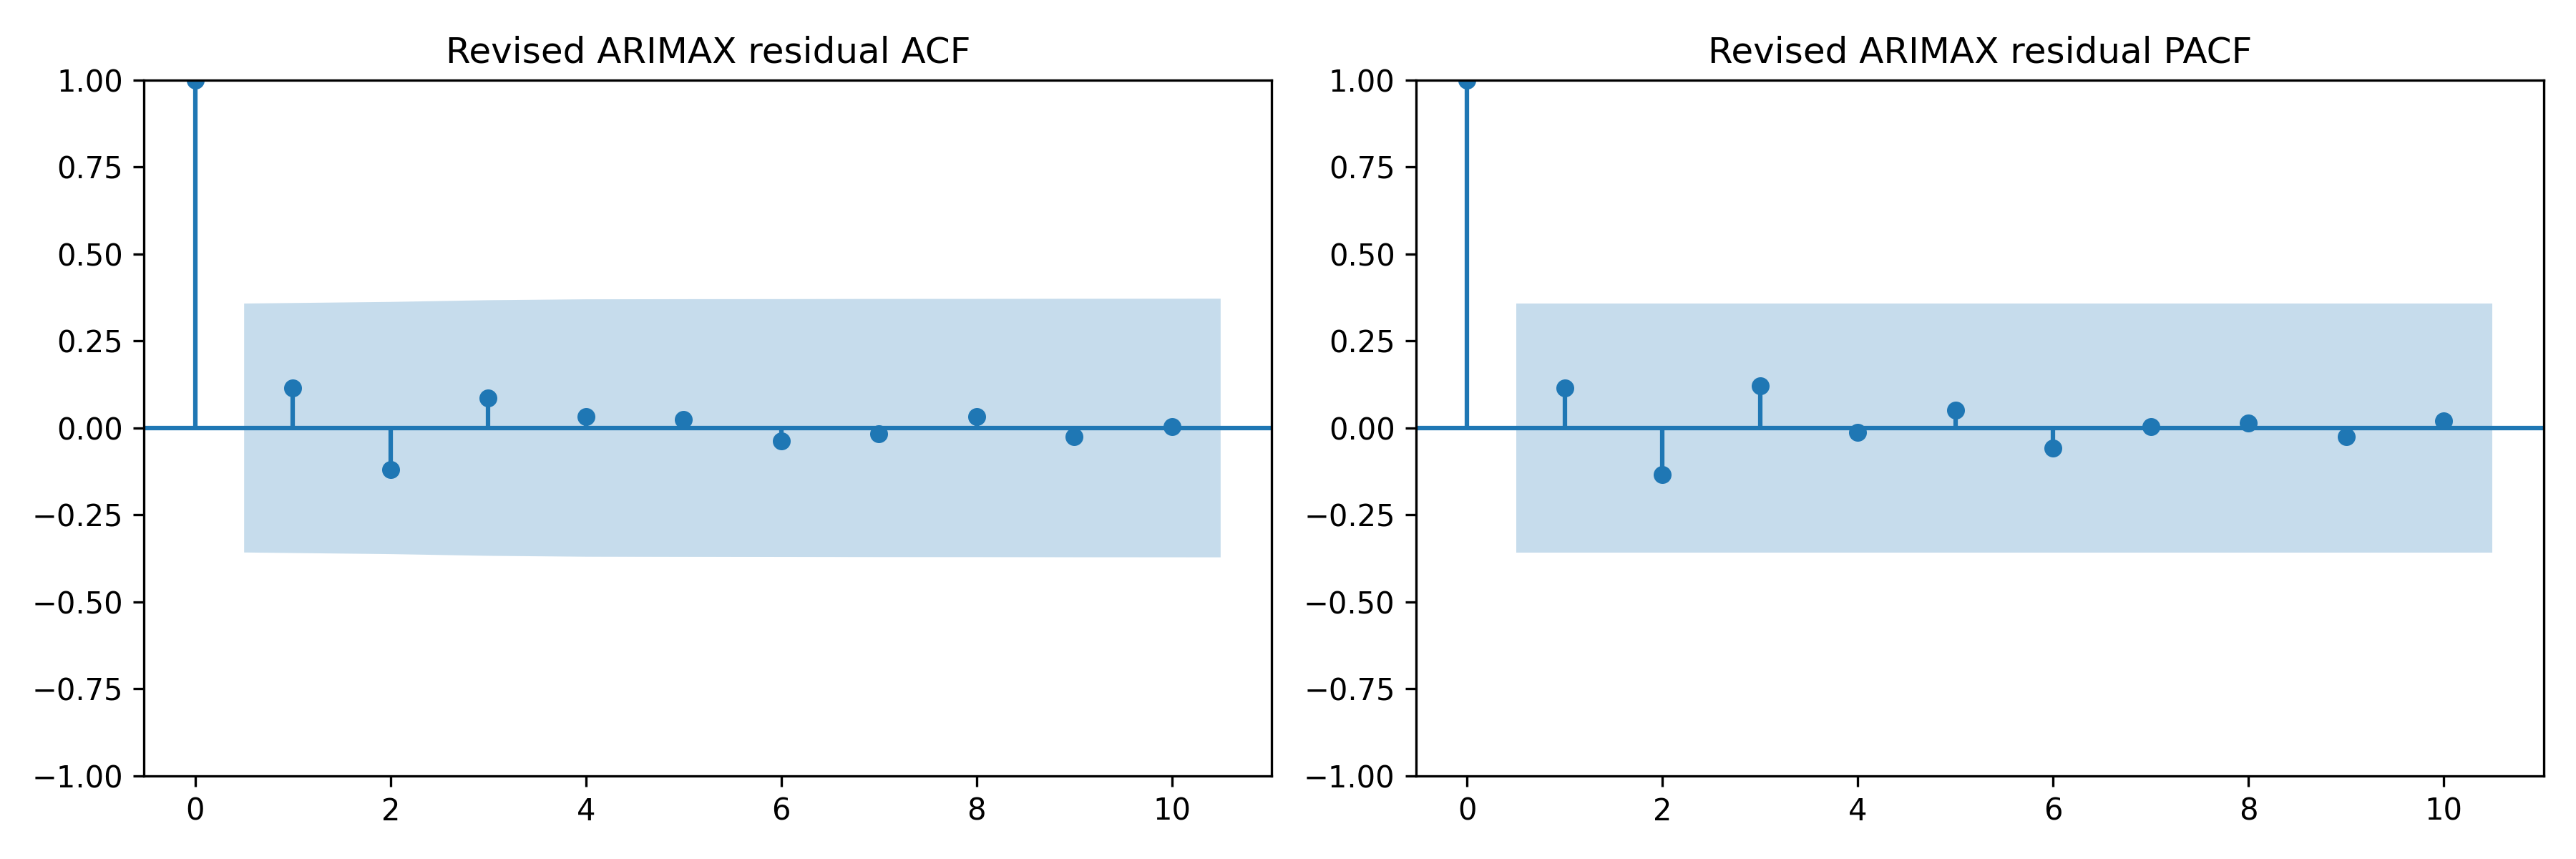

In [11]:
display(Image(filename=ROOT / "revised_autoarimax_residual_acf_pacf.png"))

## Forecast Plot

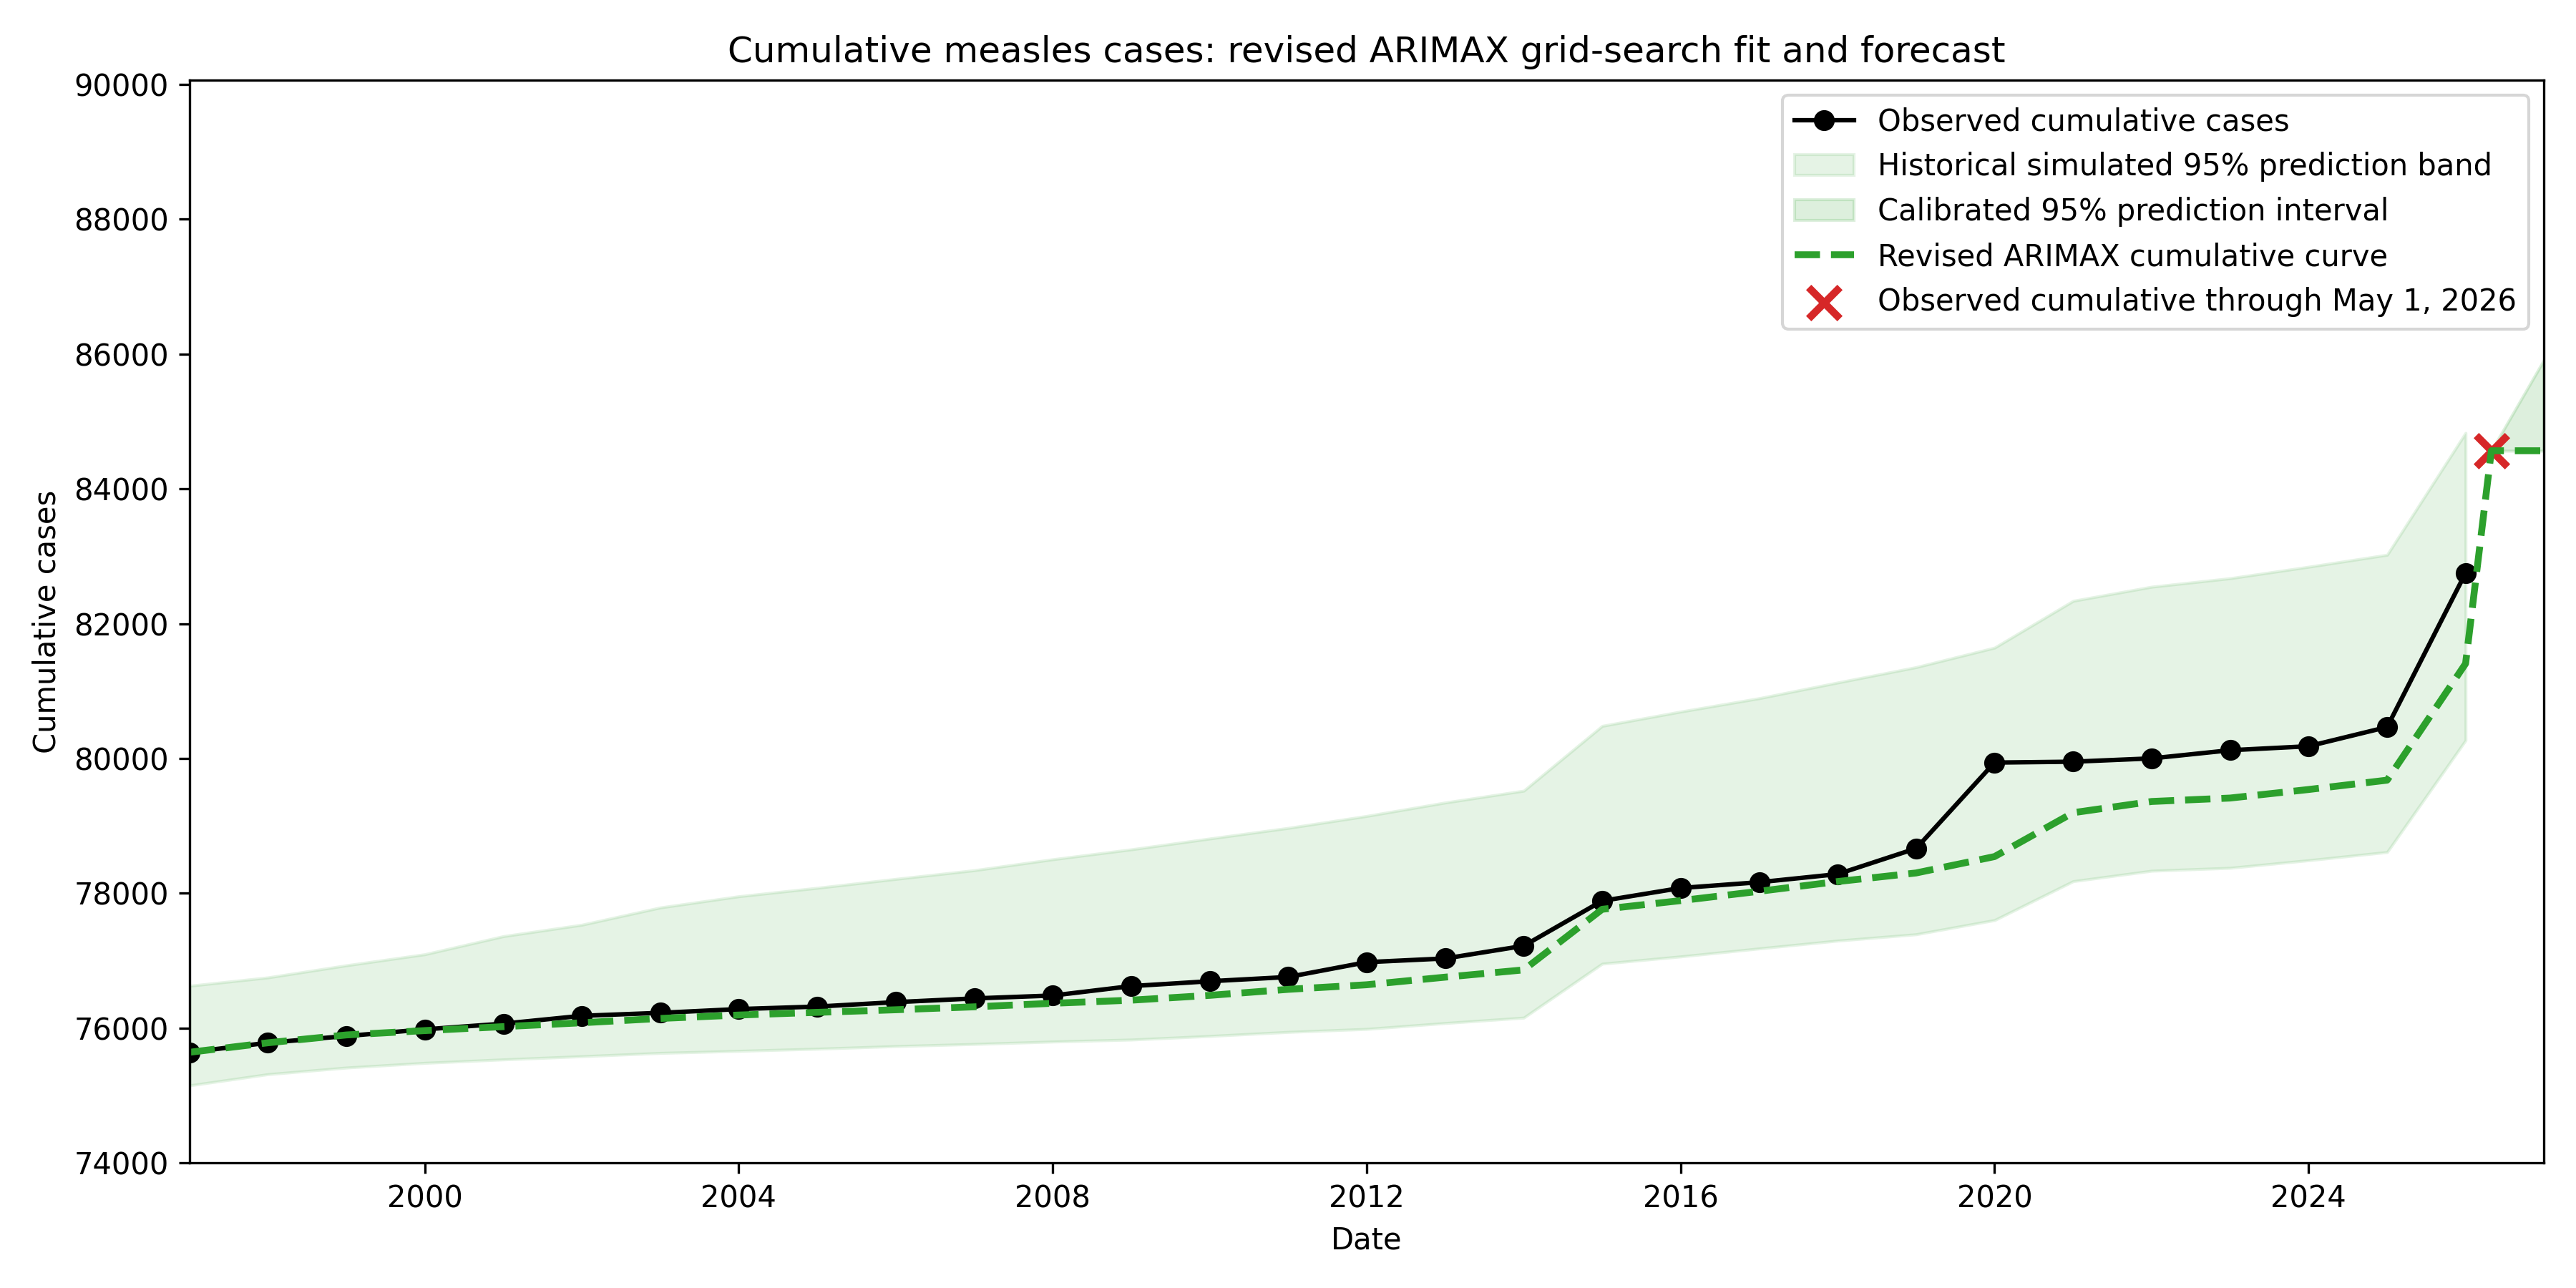

In [12]:
display(Image(filename=ROOT / "revised_autoarimax_cumulative_forecast.png"))